In [36]:
import os
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import zipfile 
from pathlib import Path

import missingno as msno

In [37]:
zip_path = Path("C:\\Users\\chris\\Initiez_vous_au_ML_Ops\\Projet+Mise+en+prod+-+home-credit-default-risk.zip")
extract_dir = Path("data")

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

print("Extraction terminée !")

Extraction terminée !


In [38]:
credit_card_balance = pd.read_csv(r"C:\Users\chris\Initiez_vous_au_ML_Ops\data\credit_card_balance.csv")
print('Credit card balance data shape: ', credit_card_balance.shape)
credit_card_balance.head()

Credit card balance data shape:  (3840312, 23)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


<Axes: >

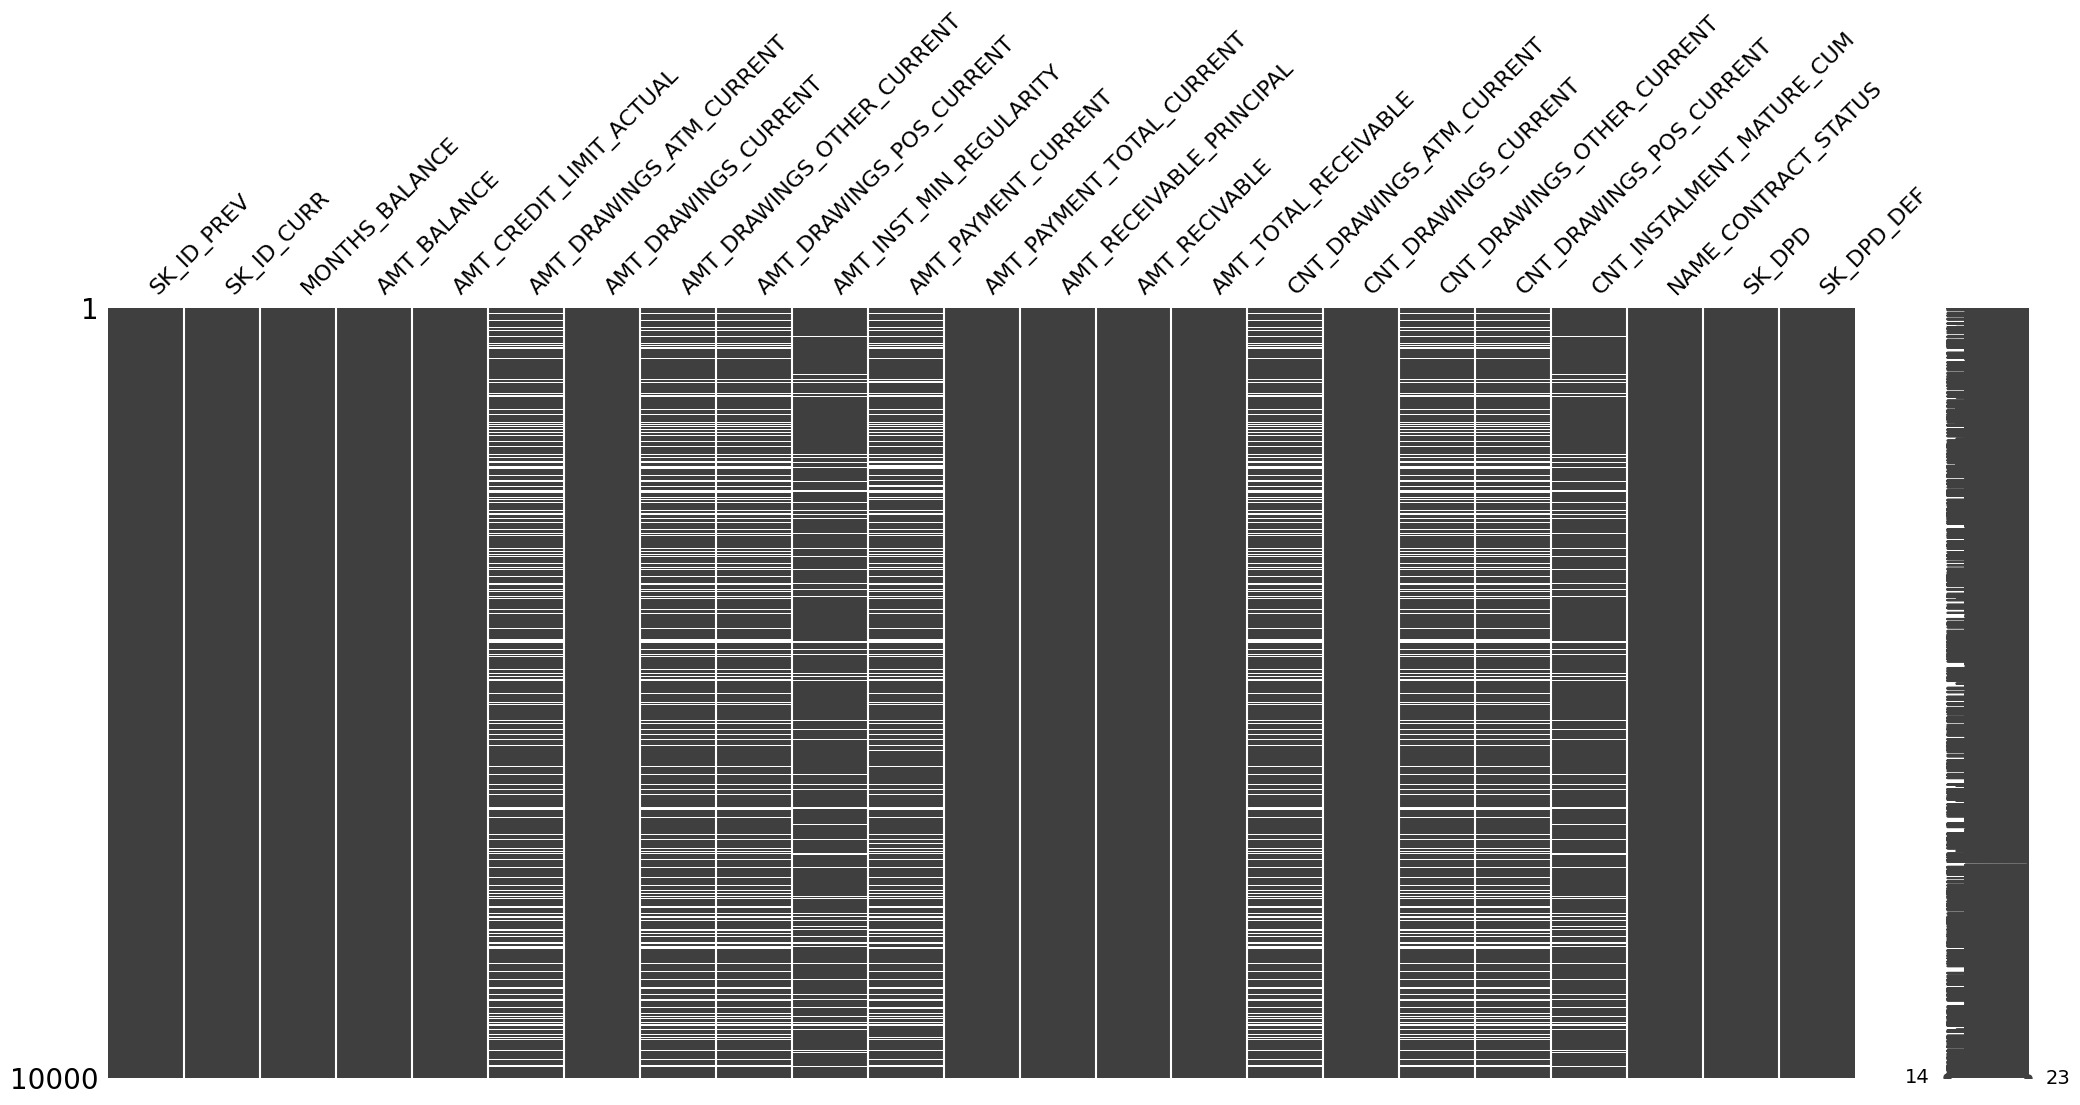

In [39]:
%matplotlib inline
msno.matrix(credit_card_balance.sample(10000))

In [40]:
credit_card_balance.duplicated();

In [41]:
credit_card_balance.isnull().mean() * 100

SK_ID_PREV                     0.000000
SK_ID_CURR                     0.000000
MONTHS_BALANCE                 0.000000
AMT_BALANCE                    0.000000
AMT_CREDIT_LIMIT_ACTUAL        0.000000
AMT_DRAWINGS_ATM_CURRENT      19.524872
AMT_DRAWINGS_CURRENT           0.000000
AMT_DRAWINGS_OTHER_CURRENT    19.524872
AMT_DRAWINGS_POS_CURRENT      19.524872
AMT_INST_MIN_REGULARITY        7.948208
AMT_PAYMENT_CURRENT           19.998063
AMT_PAYMENT_TOTAL_CURRENT      0.000000
AMT_RECEIVABLE_PRINCIPAL       0.000000
AMT_RECIVABLE                  0.000000
AMT_TOTAL_RECEIVABLE           0.000000
CNT_DRAWINGS_ATM_CURRENT      19.524872
CNT_DRAWINGS_CURRENT           0.000000
CNT_DRAWINGS_OTHER_CURRENT    19.524872
CNT_DRAWINGS_POS_CURRENT      19.524872
CNT_INSTALMENT_MATURE_CUM      7.948208
NAME_CONTRACT_STATUS           0.000000
SK_DPD                         0.000000
SK_DPD_DEF                     0.000000
dtype: float64

In [42]:
credit_card_balance['MONTHS_BALANCE'].unique();

In [43]:
credit_card_balance['AMT_BALANCE'].unique();

In [44]:
credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL'].unique();

In [45]:
credit_card_balance['AMT_DRAWINGS_ATM_CURRENT'].value_counts();

In [46]:
credit_card_balance['AMT_DRAWINGS_CURRENT'].value_counts();

In [47]:
credit_card_balance['AMT_DRAWINGS_OTHER_CURRENT'].value_counts();

In [48]:
credit_card_balance['AMT_DRAWINGS_POS_CURRENT'].value_counts();

In [49]:
# minimum à payer
credit_card_balance['AMT_INST_MIN_REGULARITY'].value_counts();

In [50]:
credit_card_balance['AMT_PAYMENT_CURRENT'].value_counts();

In [51]:
credit_card_balance['AMT_PAYMENT_TOTAL_CURRENT'].value_counts();

In [52]:
# montant restant à payer
credit_card_balance['AMT_RECEIVABLE_PRINCIPAL'].value_counts();

In [53]:
credit_card_balance['AMT_RECIVABLE'].value_counts();

In [54]:
# montant total restant à payer
credit_card_balance['AMT_TOTAL_RECEIVABLE'].value_counts();

In [55]:
credit_card_balance['CNT_DRAWINGS_ATM_CURRENT'].value_counts();

In [56]:
credit_card_balance['CNT_DRAWINGS_CURRENT'].value_counts();

In [57]:
credit_card_balance['CNT_DRAWINGS_OTHER_CURRENT'].value_counts();

In [58]:
credit_card_balance['CNT_DRAWINGS_POS_CURRENT'].value_counts();

In [59]:
credit_card_balance['CNT_INSTALMENT_MATURE_CUM'].value_counts();

In [60]:
credit_card_balance['NAME_CONTRACT_STATUS'].value_counts();

In [61]:
# jour(s) de retard de paiement
credit_card_balance['SK_DPD'].value_counts();

In [62]:
# Retards de paiement importants
credit_card_balance['SK_DPD_DEF'].value_counts();

In [63]:
# Traiter les NaN
colonnes_zero = ['AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
                 'AMT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
                 'SK_DPD', 'SK_DPD_DEF', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT']
credit_card_balance[colonnes_zero] = credit_card_balance[colonnes_zero].fillna(0)

In [64]:
# Vérifier les colonnes non-numériques:
print(credit_card_balance.select_dtypes(exclude=['number']).columns)

Index(['NAME_CONTRACT_STATUS'], dtype='object')


In [65]:
# Encodage
credit_card_balance = pd.get_dummies(credit_card_balance, 
                                      columns=['NAME_CONTRACT_STATUS'], 
                                      prefix='STATUS')

In [66]:
credit_card_balance.drop(columns=['AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT',
                                'AMT_RECIVABLE', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_CURRENT',
                                 'CNT_DRAWINGS_POS_CURRENT'], inplace=True)

In [67]:
# Agrégation NIVEAU CRÉDIT (SK_ID_PREV)
agg_functions = {
    'MONTHS_BALANCE': ['min', 'max', 'mean'],  # Ancienneté du crédit
    'AMT_BALANCE': ['mean', 'max', 'min', 'sum'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['mean', 'max'],
    'AMT_DRAWINGS_ATM_CURRENT': ['mean', 'max', 'sum'],
    'AMT_DRAWINGS_CURRENT': ['mean', 'max', 'sum'],
    'AMT_PAYMENT_CURRENT': ['mean', 'max', 'sum'],
    'CNT_DRAWINGS_ATM_CURRENT': ['mean', 'sum'],
    'SK_DPD': ['mean', 'max', 'sum'],  # Retards
    'SK_DPD_DEF': ['mean', 'max', 'sum']
}

credit_card_prev = credit_card_balance.groupby('SK_ID_PREV').agg(agg_functions)
credit_card_prev.columns = ['CC_' + '_'.join(col).upper() for col in credit_card_prev.columns]

In [68]:
# Ajouter le nombre de relevés par crédit (sens métier = activité)
credit_card_prev['CC_COUNT_RECORDS'] = credit_card_balance.groupby('SK_ID_PREV').size()
credit_card_prev.reset_index(inplace=True)

In [69]:
# Récupérer SK_ID_CURR pour chaque crédit
credit_card_prev = credit_card_prev.merge(
    credit_card_balance[['SK_ID_PREV', 'SK_ID_CURR']].drop_duplicates(),
    on='SK_ID_PREV',
    how='left'
)

In [70]:
# Agrégation NIVEAU CLIENT (SK_ID_CURR)
credit_card_client = credit_card_prev.drop('SK_ID_PREV', axis=1).groupby('SK_ID_CURR').agg(['mean', 'max', 'min', 'sum'])
credit_card_client.columns = ['CC_CLIENT_' + '_'.join(col).upper() for col in credit_card_client.columns]

In [71]:
# Ajouter le nombre de crédits par client
credit_card_client['CC_CLIENT_NUM_CREDITS'] = credit_card_prev.groupby('SK_ID_CURR')['SK_ID_PREV'].nunique()
credit_card_client.reset_index(inplace=True)

print(f"Shape finale : {credit_card_client.shape}")

Shape finale : (103558, 110)


In [72]:
credit_card_client.columns.tolist()


['SK_ID_CURR',
 'CC_CLIENT_CC_MONTHS_BALANCE_MIN_MEAN',
 'CC_CLIENT_CC_MONTHS_BALANCE_MIN_MAX',
 'CC_CLIENT_CC_MONTHS_BALANCE_MIN_MIN',
 'CC_CLIENT_CC_MONTHS_BALANCE_MIN_SUM',
 'CC_CLIENT_CC_MONTHS_BALANCE_MAX_MEAN',
 'CC_CLIENT_CC_MONTHS_BALANCE_MAX_MAX',
 'CC_CLIENT_CC_MONTHS_BALANCE_MAX_MIN',
 'CC_CLIENT_CC_MONTHS_BALANCE_MAX_SUM',
 'CC_CLIENT_CC_MONTHS_BALANCE_MEAN_MEAN',
 'CC_CLIENT_CC_MONTHS_BALANCE_MEAN_MAX',
 'CC_CLIENT_CC_MONTHS_BALANCE_MEAN_MIN',
 'CC_CLIENT_CC_MONTHS_BALANCE_MEAN_SUM',
 'CC_CLIENT_CC_AMT_BALANCE_MEAN_MEAN',
 'CC_CLIENT_CC_AMT_BALANCE_MEAN_MAX',
 'CC_CLIENT_CC_AMT_BALANCE_MEAN_MIN',
 'CC_CLIENT_CC_AMT_BALANCE_MEAN_SUM',
 'CC_CLIENT_CC_AMT_BALANCE_MAX_MEAN',
 'CC_CLIENT_CC_AMT_BALANCE_MAX_MAX',
 'CC_CLIENT_CC_AMT_BALANCE_MAX_MIN',
 'CC_CLIENT_CC_AMT_BALANCE_MAX_SUM',
 'CC_CLIENT_CC_AMT_BALANCE_MIN_MEAN',
 'CC_CLIENT_CC_AMT_BALANCE_MIN_MAX',
 'CC_CLIENT_CC_AMT_BALANCE_MIN_MIN',
 'CC_CLIENT_CC_AMT_BALANCE_MIN_SUM',
 'CC_CLIENT_CC_AMT_BALANCE_SUM_MEAN',
 'CC_CLIE